# cable Workflow

推荐入口 notebook：选择一个主配置 JSON，运行该 config 声明的全部模板，并完成 config 级 summary 与模板级 case 钻取。


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
from IPython.display import display


def find_repo_root(start=None):
    cwd = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "braincell").exists() and (candidate / "examples").exists():
            return candidate
    raise RuntimeError("Run this notebook from the repository root or a subdirectory inside it.")


REPO_ROOT = find_repo_root()
CABLE_ROOT = REPO_ROOT / "examples" / "neuron_compare" / "cable"
WORKFLOWS_ROOT = CABLE_ROOT / "workflows"
if str(WORKFLOWS_ROOT) not in sys.path:
    sys.path.insert(0, str(WORKFLOWS_ROOT))

import workflow_api


ERROR:2026-04-25 17:58:12,372:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/swl/braincell/examples/neuron_compare/cable/engine/run.py", line 12, in <module>
    from .compare import compare_case
ImportError: attempted relative import with no known parent package

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/swl/braincell/examples/neuron_compare/cable/engine/compare.py", line 12, in <module>
    from .braincell_runner import run_case as run_braincell_case
ImportError: attempted relative import with no known parent package

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home

## Parameters

这里只手动设置主配置路径。模板列表由 config 自己声明。


In [2]:
config_path = CABLE_ROOT / "configs" / "GrC.json"
out_dir = None
plot_cases = True
expand_only = False
raise_on_failure = True
selected_template_name = None
selected_case_id = None


## Input Preview

In [3]:
inputs = workflow_api.load_config_workflow_inputs(config_path)
print("config_path:", inputs["config_path"])
print("config_name:", inputs["config_name"])
print("template_names:", inputs["template_names"])
print("n_templates:", inputs["n_templates"])
print("default_out_dir:", inputs["default_out_dir"])


config_path: /home/swl/braincell/examples/neuron_compare/cable/configs/GrC.json
config_name: GrC
template_names: ('ac', 'dc', 'vinit', 'cv')
n_templates: 4
default_out_dir: /home/swl/braincell/examples/neuron_compare/cable/results/config_runs/GrC


## Run Workflow

In [4]:
run_info = workflow_api.run_notebook_config_workflow(
    config_path=config_path,
    out_dir=out_dir,
    plot=plot_cases,
    expand_only=expand_only,
    raise_on_failure=raise_on_failure,
)
print("status:", run_info["status"])
print("config_name:", run_info["config_name"])
print("out_dir:", run_info["out_dir"])
print("n_templates:", run_info["n_templates"])
print(json.dumps(run_info["status_counts"], indent=2, ensure_ascii=False))

selected_template_name = selected_template_name or next(
    (row["template_name"] for row in run_info["template_runs"] if row["batch_status"] in {"ok", "partial"}),
    None,
)
print("selected_template_name:", selected_template_name)

selected_template_out_dir = None
tables = None
if not expand_only and selected_template_name is not None:
    selected_template_out_dir = next(
        Path(row["out_dir"])
        for row in run_info["template_runs"]
        if row["template_name"] == selected_template_name
    )
    tables = workflow_api.build_summary_tables(selected_template_out_dir)
    print("selected_template_out_dir:", selected_template_out_dir)
else:
    print("No runnable template summary available.")


--No graphics will be displayed.
/home/swl/braincell/braincell/io/asc/reader.py:584: UserWarning: from_points() produced 3 zero-length segment(s) from coincident consecutive points at index pair(s) [1, 3, 5]. These degenerate segments are kept but contribute zero volume.
  return branch_class_for_type(segment.branch_type).from_points(



103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read

103 lines read
status: 0
config_name: GrC
out_dir: /home/swl/braincell/examples/neuron_compare/cable/results/config_runs/GrC
n_templates: 4
{
  "ok": 4,
  "partial": 0,
  "failed": 0
}
selected_template_name: ac
selected_template_out_dir: /home/swl/braincell/examples/neuron_compare/cable/results/config_runs/GrC/templates/ac


,case_id,group_id,status,stimulus_kind,morphology_kind,morphology_path,dt_ms,cv_per_branch,observable,n_samples,...,simulation.v_init_mV,stimulus.amplitude_nA,stimulus.duration_ms,stimulus.frequency_hz,stimulus.kind,stimulus.offset_nA,stimulus.phase_rad,stimulus.start_ms,stimulus.target,morphology_name
0,ac__008,ac,ok,sine,asc,/home/swl/braincell/examples/multi_compartment...,0.025,3,voltage_sum,80,...,-65.0,0.10,2.0,250.0,sine,0.0,0.0,0.0,root_soma_midpoint,GrC.asc
1,ac__007,ac,ok,sine,asc,/home/swl/braincell/examples/multi_compartment...,0.025,3,voltage_sum,80,...,-65.0,0.10,2.0,100.0,sine,0.0,0.0,0.0,root_soma_midpoint,GrC.asc
2,ac__005,ac,ok,sine,asc,/home/swl/braincell/examples/multi_compartment...,0.025,3,voltage_sum,80,...,-65.0,0.05,2.0,250.0,sine,0.0,0.0,0.0,root_soma_midpoint,GrC.asc
3,ac__004,ac,ok,sine,asc,/home/swl/braincell/examples/multi_compartment...,0.025,3,voltage_sum,80,...,-65.0,0.05,2.0,100.0,sine,0.0,0.0,0.0,root_soma_midpoint,GrC.asc
4,ac__006,ac,ok,sine,asc,/home/swl/braincell/examples/multi_compartment...,0.025,3,voltage_sum,80,...,-65.0,0.10,2.0,25.0,sine,0.0,0.0,0.0,root_soma_midpoint,GrC.asc
5,ac__002,ac,ok,sine,asc,/home/swl/braincell/examples/multi_compartment...,0.025,3,voltage_sum,80,...,-65.0,0.02,2.0,250.0,sine,0.0,0.0,0.0,root_soma_midpoint,GrC.asc
6,ac__001,ac,ok,sine,asc,/home/swl/braincell/examples/multi_compartment...,0.025,3,voltage_sum,80,...,-65.0,0.02,2.0,100.0,sine,0.0,0.0,0.0,root_soma_midpoint,GrC.asc
7,ac__003,ac,ok,sine,asc,/home/swl/braincell/examples/multi_compartment...,0.025,3,voltage_sum,80,...,-65.0,0.05,2.0,25.0,sine,0.0,0.0,0.0,root_soma_midpoint,GrC.asc
8,ac__008,ac,ok,sine,asc,/home/swl/braincell/examples/multi_compartment...,0.025,3,voltage_midpoint_mean,80,...,-65.0,0.10,2.0,250.0,sine,0.0,0.0,0.0,root_soma_midpoint,GrC.asc
9,ac__007,ac,ok,sine,asc,/home/swl/braincell/examples/multi_compartment...,0.025,3,voltage_midpoint_mean,80,...,-65.0,0.10,2.0,100.0,sine,0.0,0.0,0.0,root_soma_midpoint,GrC.asc


,case_id,group_id,status,stimulus_kind,morphology_kind,morphology_path,dt_ms,cv_per_branch,observable,n_samples,...,simulation.v_init_mV,stimulus.amplitude_nA,stimulus.duration_ms,stimulus.frequency_hz,stimulus.kind,stimulus.offset_nA,stimulus.phase_rad,stimulus.start_ms,stimulus.target,morphology_name


,morphology_name,n_rows,n_cases,mae_mean,rmse_mean,max_abs_max,rel_mae_pct_mean
0,GrC.asc,18,9,5.963371e-08,7.564013e-08,6.646009e-07,1.552868e-08


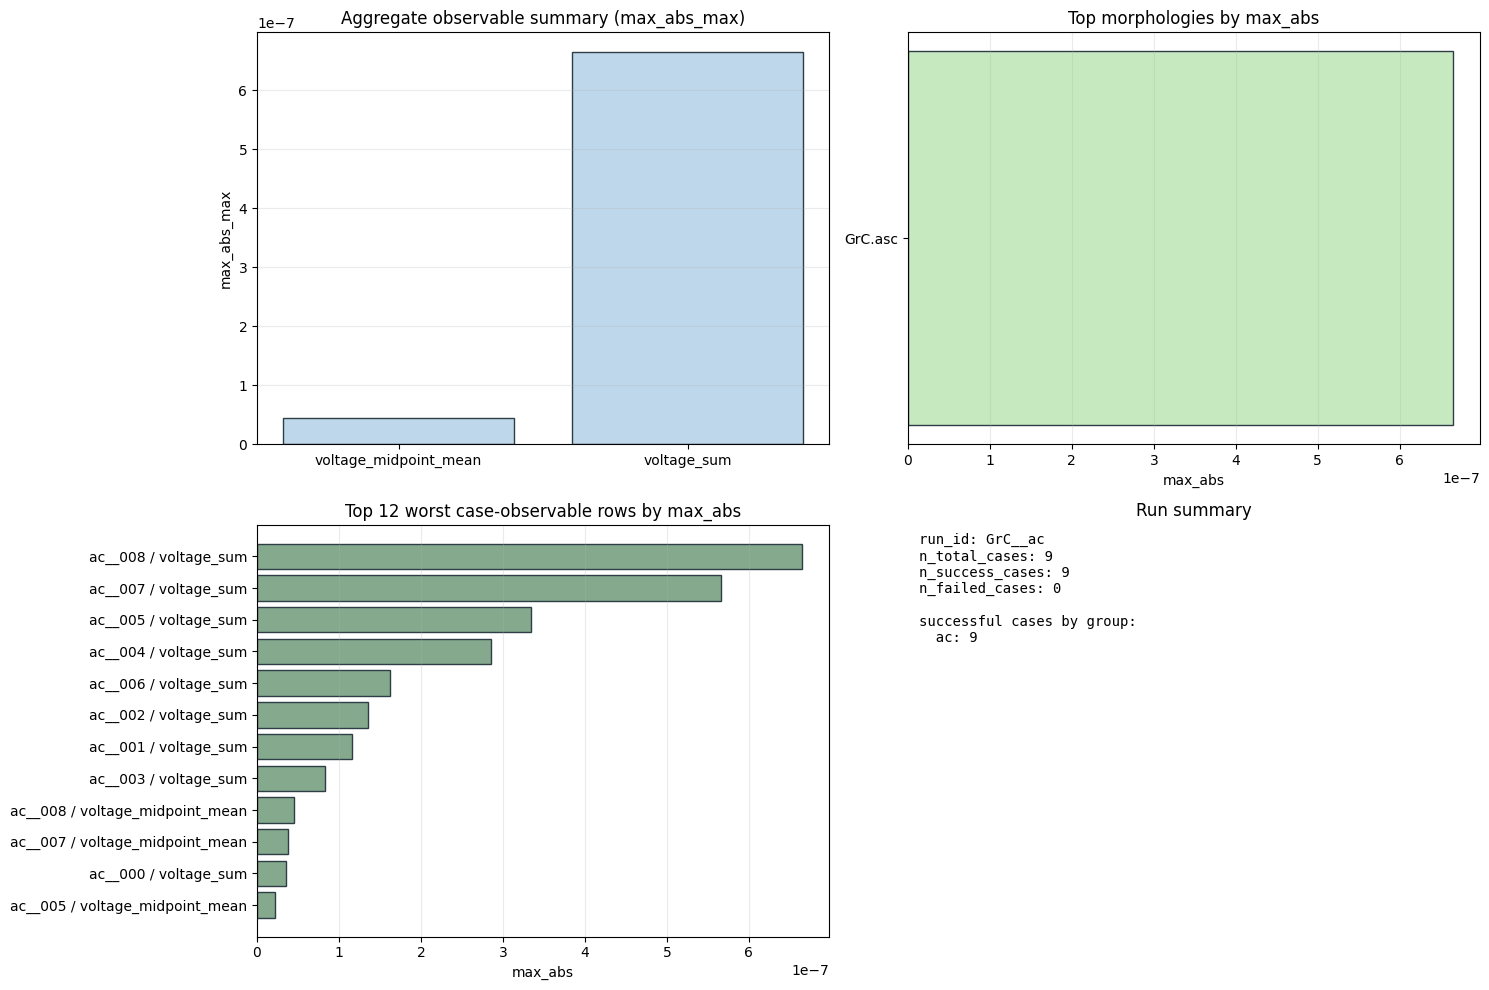

In [5]:
if tables is not None:
    display(tables["worst_cases_df"].head(20))
    display(tables["failed_df"])
    display(tables["by_morphology_df"])

    summary_fig, summary_axes = workflow_api.plot_sweep_summary(tables, metric="max_abs")
    plt.show()
else:
    print("tables is not available; did you run with expand_only=True or no successful template?")


selected_case_id: ac__008


,compartment_index,mae,max_abs,rel_mae_pct,rmse,braincell_label,neuron_label,braincell_canonical_name,neuron_canonical_name
0,8,3.085286e-08,4.851228e-08,7.913965e-08,3.498072e-08,dend[1]:cv2,dend[1]:seg2,dend[1],dend[1]
1,11,3.085286e-08,4.851228e-08,7.913965e-08,3.498072e-08,dend[2]:cv2,dend[2]:seg2,dend[2],dend[2]
2,7,2.478713e-08,4.482009e-08,6.363748e-08,2.939668e-08,dend[1]:cv1,dend[1]:seg1,dend[1],dend[1]
3,10,2.478713e-08,4.482009e-08,6.363748e-08,2.939668e-08,dend[2]:cv1,dend[2]:seg1,dend[2],dend[2]
4,5,2.309996e-08,4.438241e-08,5.925296e-08,2.792021e-08,dend[0]:cv2,dend[0]:seg2,dend[0],dend[0]
5,14,2.309996e-08,4.438241e-08,5.925296e-08,2.792021e-08,dend[3]:cv2,dend[3]:seg2,dend[3],dend[3]
6,4,1.974686e-08,4.411880e-08,5.069729e-08,2.516023e-08,dend[0]:cv1,dend[0]:seg1,dend[0],dend[0]
7,13,1.974686e-08,4.411880e-08,5.069729e-08,2.516023e-08,dend[3]:cv1,dend[3]:seg1,dend[3],dend[3]
8,0,1.951507e-08,4.411057e-08,5.025837e-08,2.497456e-08,soma[0]:cv0,soma[0]:seg0,soma[0],soma[0]
9,2,1.950619e-08,4.411005e-08,5.023552e-08,2.496736e-08,soma[0]:cv2,soma[0]:seg2,soma[0],soma[0]


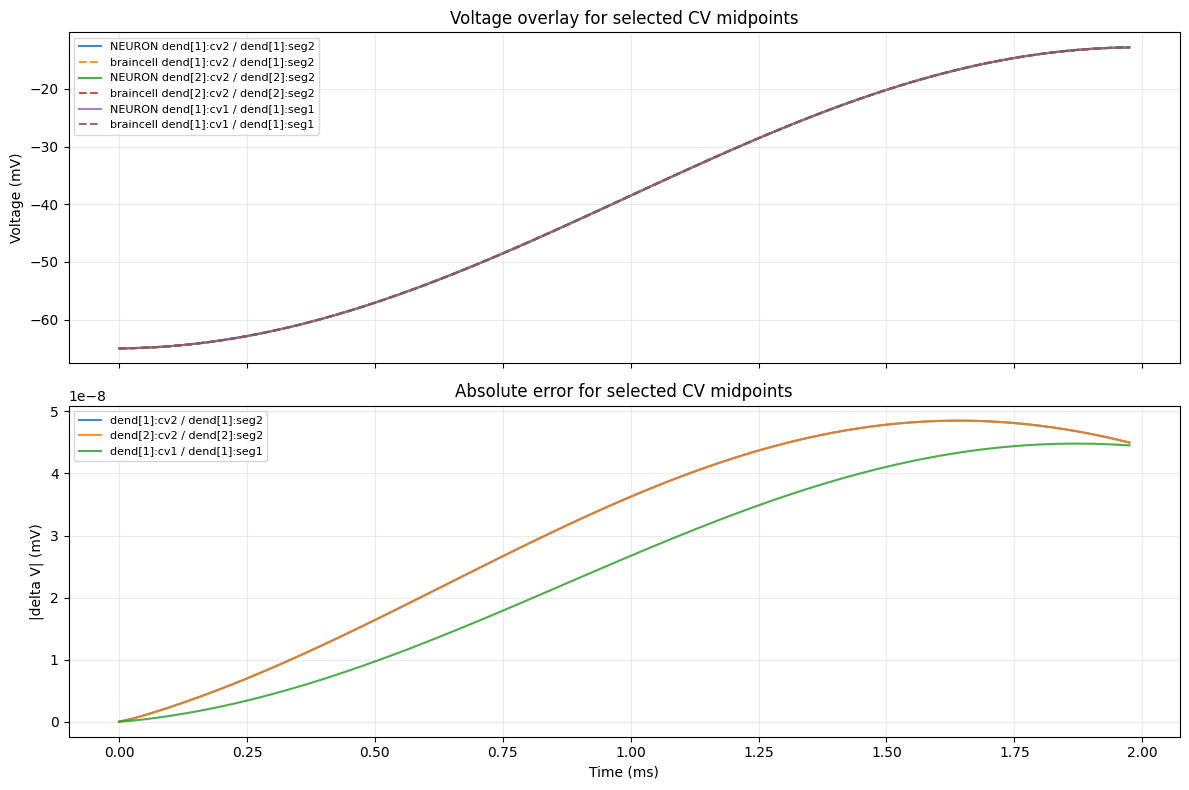

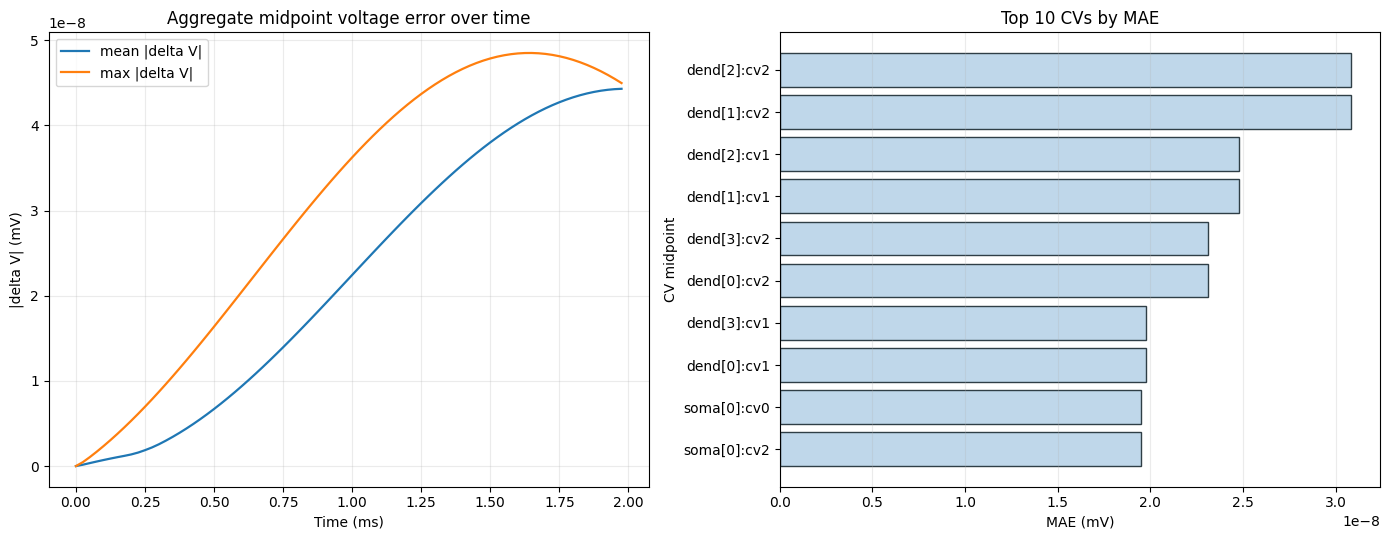

In [6]:
selected_case_id = selected_case_id or (
    tables["worst_cases_df"].iloc[0]["case_id"]
    if tables is not None and not tables["worst_cases_df"].empty
    else None
)
print("selected_case_id:", selected_case_id)

if selected_case_id is not None and selected_template_out_dir is not None:
    case_result = workflow_api.load_case_result(selected_template_out_dir, selected_case_id)
    case_metrics_df = workflow_api.build_case_metric_table(case_result)
    display(case_metrics_df.head(15))

    workflow_api.plot_case_overlay(case_result, max_compartments=3)
    plt.show()

    workflow_api.plot_case_error_summary(case_result, top_k=10)
    plt.show()
else:
    print("No successful case available for drill-down.")
